## Classification

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

!wget $data -O data-week-3.csv

--2026-10-09 13:28:05--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘data-week-3.csv’

data-week-3.csv     100%[===================>] 954.59K  --.-KB/s    in 0.004s  

2026-10-09 13:28:05 (209 MB/s) - ‘data-week-3.csv’ saved [977501/977501]



In [26]:
df = pd.read_csv('data-week-3.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [28]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [29]:
pd.to_numeric(df.TotalCharges)

ValueError: Unable to parse string " " at position 488

In [30]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [31]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')
tc.isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: totalcharges, Length: 7043, dtype: bool

In [32]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


In [91]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

In [34]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


In [35]:
df.churn

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: churn, Length: 7043, dtype: str

In [36]:
df.churn = (df.churn == 'Yes').astype(int)
df.churn

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int64

In [41]:
#Validation framework

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
train_test_split?

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of array-like of shape (n_samples,) or             (n_samples, n_outputs)
    Indexable data-structures can be arrays, lists, dataframes, scipy
    sparse matrices or pandas dataframes with consistent first dimension.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement 

In [44]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
len(df_full_train), len(df_test)

(5634, 1409)

In [45]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val)

(4225, 1409)

In [46]:
df_train = df_train.reset_index(drop=True)
df_full_train = df_full_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [47]:
y_train = df_train.churn.values
y_full_train = df_full_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [48]:
del  df_train['churn']
#del  df_full_train['churn']
del  df_val['churn']
del  df_test['churn']

In [49]:
#EDA

In [50]:
df_full_train.churn.value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [51]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [52]:
df_full_train.churn.mean()

np.float64(0.26996805111821087)

In [53]:
df_full_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,1
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,0
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0781-LKXBR,Male,1,No,No,9,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.50,918.6,1
5630,3507-GASNP,Male,0,No,Yes,60,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.95,1189.9,0
5631,8868-WOZGU,Male,0,No,No,28,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.70,2979.5,1
5632,1251-KRREG,Male,0,No,No,2,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,54.40,114.1,1


In [54]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [55]:
y_full_train.value_counts()

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [56]:
df_full_train.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                 int64
dtype: object

In [130]:
numerical = ['tenure',  'totalcharges'] #'montlycharges',

In [58]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [59]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',  'phoneservice', 
               'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 
               'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']

In [60]:
df_full_train[categorical]

,gender,seniorcitizen,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod
0,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check
1,Female,0,No,No,Yes,No,DSL,Yes,Yes,Yes,Yes,No,Yes,One year,No,Credit card (automatic)
2,Male,0,Yes,No,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Bank transfer (automatic)
3,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,No,Electronic check
4,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,One year,No,Electronic check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,Male,1,No,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
5630,Male,0,No,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check
5631,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
5632,Male,0,No,No,Yes,Yes,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check


In [61]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

In [62]:
#Feature importance

In [63]:
df_full_train.partner.value_counts()

partner
No     2932
Yes    2702
Name: count, dtype: int64

In [64]:
df_full_train.gender.value_counts()

gender
Male      2838
Female    2796
Name: count, dtype: int64

In [65]:
female = df_full_train[df_full_train.gender == 'Female'].churn.mean()
male = df_full_train[df_full_train.gender == 'Male'].churn.mean()
female, male

(np.float64(0.27682403433476394), np.float64(0.2632135306553911))

In [66]:
partner = df_full_train[df_full_train.partner == 'Yes'].churn.mean()
single = df_full_train[df_full_train.partner == 'No'].churn.mean()
partner, single

(np.float64(0.20503330866025166), np.float64(0.3298090040927694))

In [67]:
df_full_train.groupby('gender').churn.mean()

gender
Female    0.276824
Male      0.263214
Name: churn, dtype: float64

In [68]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.26996805111821087)

In [69]:
df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count'])
df_group

,mean,count
gender,,
Female,0.276824,2796
Male,0.263214,2838


In [70]:
df_group['diff'] = df_group['mean'] - global_churn
df_group['risk'] = df_group['mean'] / global_churn
df_group

,mean,count,diff,risk
gender,,,,
Female,0.276824,2796,0.006856,1.025396
Male,0.263214,2838,-0.006755,0.974980


In [71]:
from IPython.display import display

In [72]:
for c in categorical:
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()

,mean,count,diff,risk
gender,,,,
Female,0.276824,2796,0.006856,1.025396
Male,0.263214,2838,-0.006755,0.974980


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208


,mean,count,diff,risk
partner,,,,
No,0.329809,2932,0.059841,1.221659
Yes,0.205033,2702,-0.064935,0.759472


,mean,count,diff,risk
dependents,,,,
No,0.313760,3968,0.043792,1.162212
Yes,0.165666,1666,-0.104302,0.613651


,mean,count,diff,risk
phoneservice,,,,
No,0.241316,547,-0.028652,0.893870
Yes,0.273049,5087,0.003081,1.011412


,mean,count,diff,risk
multiplelines,,,,
No,0.257407,2700,-0.012561,0.953474
No phone service,0.241316,547,-0.028652,0.893870
Yes,0.290742,2387,0.020773,1.076948


,mean,count,diff,risk
internetservice,,,,
DSL,0.192347,1934,-0.077621,0.712482
Fiber optic,0.425171,2479,0.155203,1.574895
No,0.077805,1221,-0.192163,0.288201


,mean,count,diff,risk
onlinesecurity,,,,
No,0.420921,2801,0.150953,1.559152
No internet service,0.077805,1221,-0.192163,0.288201
Yes,0.153226,1612,-0.116742,0.567570


,mean,count,diff,risk
onlinebackup,,,,
No,0.404323,2498,0.134355,1.497672
No internet service,0.077805,1221,-0.192163,0.288201
Yes,0.217232,1915,-0.052736,0.804660


,mean,count,diff,risk
deviceprotection,,,,
No,0.395875,2473,0.125907,1.466379
No internet service,0.077805,1221,-0.192163,0.288201
Yes,0.230412,1940,-0.039556,0.853480


,mean,count,diff,risk
techsupport,,,,
No,0.418914,2781,0.148946,1.551717
No internet service,0.077805,1221,-0.192163,0.288201
Yes,0.159926,1632,-0.110042,0.592390


,mean,count,diff,risk
streamingtv,,,,
No,0.342832,2246,0.072864,1.269897
No internet service,0.077805,1221,-0.192163,0.288201
Yes,0.302723,2167,0.032755,1.121328


,mean,count,diff,risk
streamingmovies,,,,
No,0.338906,2213,0.068938,1.255358
No internet service,0.077805,1221,-0.192163,0.288201
Yes,0.307273,2200,0.037305,1.138182


,mean,count,diff,risk
contract,,,,
Month-to-month,0.431701,3104,0.161733,1.599082
One year,0.120573,1186,-0.149395,0.446621
Two year,0.028274,1344,-0.241694,0.104730


,mean,count,diff,risk
paperlessbilling,,,,
No,0.172071,2313,-0.097897,0.637375
Yes,0.338151,3321,0.068183,1.252560


,mean,count,diff,risk
paymentmethod,,,,
Bank transfer (automatic),0.168171,1219,-0.101797,0.622928
Credit card (automatic),0.164339,1217,-0.105630,0.608733
Electronic check,0.455890,1893,0.185922,1.688682
Mailed check,0.193870,1305,-0.076098,0.718121


In [83]:
##Mutual information

In [74]:
from sklearn.metrics import mutual_info_score

In [75]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

0.0983203874041556

In [76]:
mutual_info_score(df_full_train.contract, df_full_train.churn)

0.0983203874041556

In [77]:
mutual_info_score(df_full_train.churn, df_full_train.gender)

0.0001174846211139946

In [78]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [79]:
df_full_train[categorical].apply(mutual_info_churn_score)

gender              0.000117
seniorcitizen       0.009410
partner             0.009968
dependents          0.012346
phoneservice        0.000229
multiplelines       0.000857
internetservice     0.055868
onlinesecurity      0.063085
onlinebackup        0.046923
deviceprotection    0.043453
techsupport         0.061032
streamingtv         0.031853
streamingmovies     0.031581
contract            0.098320
paperlessbilling    0.017589
paymentmethod       0.043210
dtype: float64

In [81]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

In [82]:
##Correlation

In [93]:
df_full_train[numerical]

,tenure,totalcharges
0,12,258.35
1,42,3160.55
2,71,4681.75
3,71,6300.85
4,30,2044.75
...,...,...
5629,9,918.6
5630,60,1189.9
5631,28,2979.5
5632,2,114.1


In [95]:
df_full_train[numerical].corrwith(df_full_train.churn)

KeyError: "['montlycharges'] not in index"

In [96]:
df_full_train[df_full_train.tenure <=2].churn.mean()

np.float64(0.5953420669577875)

In [97]:
df_full_train[df_full_train.tenure >2].churn.mean()

np.float64(0.22478269658378816)

In [98]:
df_full_train[(df_full_train.tenure >2) & (df_full_train.tenure <=12) ].churn.mean()

np.float64(0.3994413407821229)

In [99]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17634908339788277)

In [100]:
df_full_train[df_full_train.monthlycharges <20].churn.mean()

np.float64(0.08829568788501027)

In [102]:
df_full_train[(df_full_train.monthlycharges >20) & (df_full_train.monthlycharges <=50) ].churn.mean()

np.float64(0.18340943683409436)

In [103]:
##One-hot encoding

In [104]:
from sklearn.feature_extraction import DictVectorizer

In [106]:
df_train[['gender', 'contract']].iloc[:10]

,gender,contract
0,Female,Two year
1,Male,Month-to-month
2,Female,Month-to-month
3,Female,Month-to-month
4,Female,Two year
5,Male,Month-to-month
6,Male,Month-to-month
7,Female,Month-to-month
8,Female,Two year
9,Female,Month-to-month


In [110]:
dicts = df_train[['gender', 'contract']].iloc[:10].to_dict(orient='records')
dicts

[{'gender': 'Female', 'contract': 'Two year'},
 {'gender': 'Male', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Two year'},
 {'gender': 'Male', 'contract': 'Month-to-month'},
 {'gender': 'Male', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Two year'},
 {'gender': 'Female', 'contract': 'Month-to-month'}]

In [119]:
dv = DictVectorizer()

In [120]:
dv.fit(dicts)

DictVectorizer()

In [121]:
dv.transform(dicts)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 20 stored elements and shape (10, 4)>

In [122]:
dv = DictVectorizer(sparse=False)

In [123]:
dv.fit(dicts)

DictVectorizer(sparse=False)

In [126]:
dv.get_feature_names_out()

array(['contract=Month-to-month', 'contract=Two year', 'gender=Female',
       'gender=Male'], dtype=object)

In [125]:
dv.transform(dicts)

array([[0., 1., 1., 0.],
       [1., 0., 0., 1.],
       [1., 0., 1., 0.],
       [1., 0., 1., 0.],
       [0., 1., 1., 0.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 1., 0.],
       [0., 1., 1., 0.],
       [1., 0., 1., 0.]])

In [133]:
train_dicts = df_train[categorical+numerical].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
dv.fit(train_dicts)
X_train = dv.fit_transform(train_dicts)

In [134]:

dv.get_feature_names_out()

array(['contract=Month-to-month', 'contract=One year',
       'contract=Two year', ..., 'totalcharges=998.1',
       'totalcharges=999.45', 'totalcharges=999.9'],
      shape=(4055,), dtype=object)

In [135]:
train_dicts = df_train[categorical+numerical].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [138]:
val_dicts = df_val[categorical+numerical].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_val = dv.fit_transform(val_dicts)

#Logistic regression

In [139]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [140]:
z= np.linspace(-5,5,51)

In [141]:
sigmoid(z)

array([0.00669285, 0.00816257, 0.0099518 , 0.01212843, 0.01477403,
       0.01798621, 0.02188127, 0.02659699, 0.03229546, 0.03916572,
       0.04742587, 0.05732418, 0.06913842, 0.0831727 , 0.09975049,
       0.11920292, 0.14185106, 0.16798161, 0.19781611, 0.23147522,
       0.26894142, 0.31002552, 0.35434369, 0.40131234, 0.450166  ,
       0.5       , 0.549834  , 0.59868766, 0.64565631, 0.68997448,
       0.73105858, 0.76852478, 0.80218389, 0.83201839, 0.85814894,
       0.88079708, 0.90024951, 0.9168273 , 0.93086158, 0.94267582,
       0.95257413, 0.96083428, 0.96770454, 0.97340301, 0.97811873,
       0.98201379, 0.98522597, 0.98787157, 0.9900482 , 0.99183743,
       0.99330715])

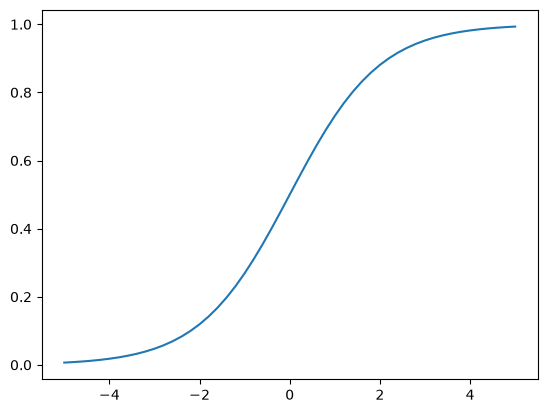

In [143]:
plt.plot(z, sigmoid(z))

In [145]:
def linear_regression(xi):
    result = w0
    
    for j in range(len(w)):
        result = result + xi[j] * w[j]

    return result
    

In [ ]:
def logistic_regression(xi):
    score = w0
    for j in range(len(w)):
        score = score + xi[j] * w[j]
        
    result = sigmoid(score)
    return result